# Test Pipeline with Linear Regression

This notebook implements a simple end-to-end pipeline for fake news detection using a linear model (Ridge Classifier).

The pipeline includes:
1. Loading preprocessed data
2. Train/test split
3. Feature extraction (TF-IDF)
4. Model training (Ridge Classifier - a linear model)
5. Evaluation


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import os
import yaml

# Add project root to path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

# Import project modules
from src.data.load_data import load_kaggle_dataset
from src.data.make_split import make_split, make_split_from_config
from src.features.make_features import load_split_data, create_tfidf_features
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Helper function to load config
def load_config(config_path="config/config.yaml"):
    with open(config_path, "r") as f:
        return yaml.safe_load(f)

print("✓ Imports successful")


✓ Imports successful


In [2]:
from src.data.load_data import load_kaggle_dataset, save_processed_data
from src.preprocessing import preprocess_dataframe, tokenize_dataframe

print("Generating preprocessed dataset...")

# Define paths
raw_data_path = project_root / "data" / "raw" / "WELFake_Dataset.csv"
processed_data_path = project_root / "data" / "processed" / "preprocessed_dataset.csv"

# 1. Load Data
df = load_kaggle_dataset(raw_data_path)
print(f"Loaded {len(df)} rows.")

# 2. Tokenize
print("Tokenizing...")
df = tokenize_dataframe(df, text_column="text", output_column="tokens")

# 3. Apply Preprocessing (cleaning, lemmatization, etc.)
print("Preprocessing (this may take a moment)...")
df = preprocess_dataframe(
    df,
    text_column="text",
    output_column="processed_tokens",
    lowercase=True,
    remove_punct=True,
    remove_stops=True,
    remove_nums=False,
    min_length=3,
    stem=False,
    lemmatize=True
)

# 4. Save
columns_to_save = ["id", "title", "text", "tokens", "processed_tokens", "label"]
save_processed_data(df, processed_data_path, columns=columns_to_save)
print("✓ Preprocessed dataset created successfully.")

Generating preprocessed dataset...
Loaded 72134 rows.
Tokenizing...
Preprocessing (this may take a moment)...
✓ Saved 72134 rows to /Users/alanye/Fake-News-Group-3/data/processed/preprocessed_dataset.csv
✓ Preprocessed dataset created successfully.


## Step 1: Load Configuration and Data


In [3]:
# Load configuration (relative to project root)
config_path = project_root / "config" / "config.yaml"
config = load_config(str(config_path))
processed_dir = config["data"]["processed_data_dir"]

# Make processed_dir absolute path relative to project root
processed_dir_abs = project_root / processed_dir
print(f"Processed data directory: {processed_dir_abs}")

# Check if train/test split exists, if not create it
train_path = processed_dir_abs / "train.csv"
test_path = processed_dir_abs / "test.csv"

if not train_path.exists() or not test_path.exists():
    print("Train/test split not found. Creating split...")
    input_path = processed_dir_abs / config["data"]["cleaned_dataset"]
    make_split(
        input_path=str(input_path),
        output_dir=str(processed_dir_abs),
        test_size=config["models"]["test_size"],
        random_seed=config["models"]["random_seed"]
    )

# Load train and test data (use absolute path)
train_df, test_df = load_split_data(str(processed_dir_abs))
print(f"\nTrain set: {len(train_df)} samples")
print(f"Test set: {len(test_df)} samples")
print(f"\nTrain set columns: {train_df.columns.tolist()}")
print(f"\nLabel distribution (train):")
print(train_df["label"].value_counts())


Processed data directory: /Users/alanye/Fake-News-Group-3/data/processed
Train/test split not found. Creating split...
Loading data from /Users/alanye/Fake-News-Group-3/data/processed/preprocessed_dataset.csv...
Checking for duplicates...
Removed 9415 duplicate rows. New size: 62719
Splitting data (test_size=0.2, random_seed=42)...
Saving train set to /Users/alanye/Fake-News-Group-3/data/processed/train.csv (50175 rows)...
Saving test set to /Users/alanye/Fake-News-Group-3/data/processed/test.csv (12544 rows)...
Split complete!

Train set: 50175 samples
Test set: 12544 samples

Train set columns: ['id', 'title', 'text', 'tokens', 'processed_tokens', 'label']

Label distribution (train):
label
0    27696
1    22479
Name: count, dtype: int64


In [4]:
# Check for duplicates WITHIN each set
print("Duplicates within train set:")
train_dups = train_df['text'].duplicated().sum()
print(f"  Duplicate rows: {train_dups:,}")
print(f"  Unique texts: {train_df['text'].nunique():,}")
print(f"  Total rows: {len(train_df):,}")

print("\nDuplicates within test set:")
test_dups = test_df['text'].duplicated().sum()
print(f"  Duplicate rows: {test_dups:,}")
print(f"  Unique texts: {test_df['text'].nunique():,}")
print(f"  Total rows: {len(test_df):,}")


Duplicates within train set:
  Duplicate rows: 0
  Unique texts: 50,174
  Total rows: 50,175

Duplicates within test set:
  Duplicate rows: 0
  Unique texts: 12,544
  Total rows: 12,544


In [5]:
import pandas as pd

# Assuming you have df, train_df, and test_df loaded
# If not, load them first:
df = pd.read_csv('../data/processed/preprocessed_dataset.csv')
# train_df = pd.read_csv('data/processed/train.csv')
# test_df = pd.read_csv('data/processed/test.csv')

# =============================================================================
# 1. FIND DUPLICATES IN ORIGINAL DATASET
# =============================================================================
print("=" * 80)
print("DUPLICATE ANALYSIS - ORIGINAL DATASET")
print("=" * 80)

# Find texts that appear more than once
text_counts = df['text'].value_counts()
duplicated_texts = text_counts[text_counts > 1]

print(f"\nTotal articles: {len(df):,}")
print(f"Unique texts: {df['text'].nunique():,}")
print(f"Duplicate texts: {len(duplicated_texts):,}")
print(f"Total duplicate rows: {df['text'].duplicated().sum():,}")

# Show distribution of duplicates
print(f"\nDuplicate frequency distribution:")
print(f"  Texts appearing 2 times: {(duplicated_texts == 2).sum():,}")
print(f"  Texts appearing 3 times: {(duplicated_texts == 3).sum():,}")
print(f"  Texts appearing 4+ times: {(duplicated_texts >= 4).sum():,}")
print(f"  Max occurrences: {duplicated_texts.max()}")

# =============================================================================
# 2. SHOW SAMPLE DUPLICATES - TOP 5 MOST DUPLICATED
# =============================================================================
print("\n" + "=" * 80)
print("TOP 5 MOST DUPLICATED TEXTS")
print("=" * 80)

for i, (text, count) in enumerate(duplicated_texts.head(5).items(), 1):
    print(f"\n{'─' * 80}")
    print(f"DUPLICATE GROUP #{i}: Appears {count} times")
    print(f"{'─' * 80}")
    
    # Get all rows with this text
    duplicate_rows = df[df['text'] == text].copy()
    
    # Show key info
    display_df = duplicate_rows[['id', 'title', 'label']].copy()
    display_df['text_preview'] = duplicate_rows['text'].str[:80] + '...'
    
    print(display_df.to_string(index=False))
    print(f"\nLabels: {duplicate_rows['label'].value_counts().to_dict()}")

# =============================================================================
# 3. SHOW DUPLICATES THAT SPAN TRAIN/TEST SPLIT (THE LEAKAGE!)
# =============================================================================
print("\n" + "=" * 80)
print("DUPLICATES THAT CAUSE TRAIN/TEST LEAKAGE")
print("=" * 80)

# Find texts that appear in BOTH train and test
train_texts_set = set(train_df['text'])
test_texts_set = set(test_df['text'])
leaked_texts = train_texts_set & test_texts_set

print(f"\nTexts appearing in BOTH train and test: {len(leaked_texts):,}")

# Show first 5 leaked texts
print("\nSample leaked texts (first 5):")
for i, leaked_text in enumerate(list(leaked_texts)[:5], 1):
    print(f"\n{'─' * 80}")
    print(f"LEAKED TEXT #{i}")
    print(f"{'─' * 80}")
    
    # Show where it appears in train
    train_rows = train_df[train_df['text'] == leaked_text]
    print(f"\nIn TRAIN set ({len(train_rows)} occurrences):")
    print(train_rows[['id', 'title', 'label']].to_string(index=False))
    
    # Show where it appears in test
    test_rows = test_df[test_df['text'] == leaked_text]
    print(f"\nIn TEST set ({len(test_rows)} occurrences):")
    print(test_rows[['id', 'title', 'label']].to_string(index=False))
    
    # Show preview of the actual text
    print(f"\nText preview: {leaked_text[:200]}...")

# =============================================================================
# 4. CREATE COMPREHENSIVE DUPLICATE REPORT DATAFRAME
# =============================================================================
print("\n" + "=" * 80)
print("COMPREHENSIVE DUPLICATE REPORT")
print("=" * 80)

# Create a dataframe showing all duplicate groups
duplicate_report = []

for text in duplicated_texts.head(20).index:  # Top 20 most duplicated
    rows_with_text = df[df['text'] == text]
    
    for idx, row in rows_with_text.iterrows():
        duplicate_report.append({
            'duplicate_group': text[:50] + '...',  # First 50 chars as group ID
            'occurrences': duplicated_texts[text],
            'id': row['id'],
            'title': row['title'][:60] + '...' if len(str(row['title'])) > 60 else row['title'],
            'label': row['label'],
            'in_train': text in train_texts_set,
            'in_test': text in test_texts_set,
            'causes_leakage': text in leaked_texts
        })

dup_report_df = pd.DataFrame(duplicate_report)

print("\nTop 20 duplicate groups:")
print(dup_report_df.to_string(index=False))

# Summary statistics
print("\n" + "=" * 80)
print("SUMMARY BY DUPLICATE GROUP")
print("=" * 80)

summary = dup_report_df.groupby('duplicate_group').agg({
    'occurrences': 'first',
    'causes_leakage': 'first',
    'in_train': 'first',
    'in_test': 'first'
})

print(summary.to_string())

# =============================================================================
# 5. CHECK IF DUPLICATES HAVE SAME LABELS (CONSISTENCY CHECK)
# =============================================================================
print("\n" + "=" * 80)
print("LABEL CONSISTENCY CHECK FOR DUPLICATES")
print("=" * 80)

inconsistent_labels = []

for text in duplicated_texts.head(50).index:
    rows_with_text = df[df['text'] == text]
    unique_labels = rows_with_text['label'].unique()
    
    if len(unique_labels) > 1:
        inconsistent_labels.append({
            'text_preview': text[:80] + '...',
            'occurrences': len(rows_with_text),
            'labels': unique_labels.tolist(),
            'ids': rows_with_text['id'].tolist()
        })

if inconsistent_labels:
    print(f"\n⚠️ WARNING: Found {len(inconsistent_labels)} texts with INCONSISTENT labels!")
    print("\nThese are the same text labeled differently:")
    for item in inconsistent_labels[:5]:
        print(f"\nText: {item['text_preview']}")
        print(f"  Appears {item['occurrences']} times")
        print(f"  Labels: {item['labels']}")
        print(f"  IDs: {item['ids']}")
else:
    print("✓ All duplicate texts have consistent labels")

# =============================================================================
# 6. EXPORT DUPLICATES TO CSV FOR DETAILED INSPECTION
# =============================================================================
print("\n" + "=" * 80)
print("EXPORTING DETAILED DUPLICATE DATA")
print("=" * 80)

# Export all duplicates to CSV
all_duplicates = df[df['text'].duplicated(keep=False)].copy()
all_duplicates = all_duplicates.sort_values('text')
all_duplicates['duplicate_count'] = all_duplicates.groupby('text')['text'].transform('count')

output_path = '../data/processed/duplicate_analysis.csv'
all_duplicates.to_csv(output_path, index=False)
print(f"\n✓ Exported {len(all_duplicates):,} duplicate rows to: {output_path}")
print(f"  These rows contain {all_duplicates['text'].nunique():,} unique texts")

# =============================================================================
# 7. VISUALIZATION-READY SUMMARY
# =============================================================================
print("\n" + "=" * 80)
print("QUICK STATS FOR VISUALIZATION")
print("=" * 80)

stats = {
    'Total articles': len(df),
    'Unique articles': df['text'].nunique(),
    'Duplicate articles': len(duplicated_texts),
    'Wasted rows (duplicates)': len(df) - df['text'].nunique(),
    'Train/test leakage': len(leaked_texts),
    'Leakage percentage (of test)': f"{len(leaked_texts) / len(test_texts_set) * 100:.1f}%"
}

for key, value in stats.items():
    print(f"  {key}: {value}")

DUPLICATE ANALYSIS - ORIGINAL DATASET

Total articles: 72,134
Unique texts: 62,718
Duplicate texts: 7,731
Total duplicate rows: 9,415

Duplicate frequency distribution:
  Texts appearing 2 times: 7,149
  Texts appearing 3 times: 520
  Texts appearing 4+ times: 62
  Max occurrences: 738

TOP 5 MOST DUPLICATED TEXTS

────────────────────────────────────────────────────────────────────────────────
DUPLICATE GROUP #1: Appears 738 times
────────────────────────────────────────────────────────────────────────────────
   id                                                                                                                                                                                                                            title  label text_preview
    7                                                                                                                                                  HOUSE INTEL CHAIR On Trump-Russia Fake Story: “No evidence of anything” [Video]  

In [6]:
duplicate_analysis = pd.read_csv('../data/processed/duplicate_analysis.csv')
duplicate_analysis


,id,title,text,tokens,processed_tokens,label,duplicate_count
0,28733,Hillary Is 70 Days Away From Controlling All F...,"\n\n \nIf Clinton is elected, Obama will hand ...","['If', 'Clinton', 'is', 'elected', 'Obama', 'w...","['clinton', 'elect', 'obama', 'hand', 'power',...",1,2.0
1,33501,Hillary Is 70 Days Away From Controlling All F...,"\n\n \nIf Clinton is elected, Obama will hand ...","['If', 'Clinton', 'is', 'elected', 'Obama', 'w...","['clinton', 'elect', 'obama', 'hand', 'power',...",1,2.0
2,16419,Just Another Day In the Life of the Clinton Cr...,"\n\n \nIn the past 24 hours, some very stunnin...","['In', 'the', 'past', '24', 'hours', 'some', '...","['past', 'hours', 'stun', 'piece', 'informatio...",1,2.0
3,24633,Just Another Day In the Life of the Clinton Cr...,"\n\n \nIn the past 24 hours, some very stunnin...","['In', 'the', 'past', '24', 'hours', 'some', '...","['past', 'hours', 'stun', 'piece', 'informatio...",1,2.0
4,12670,"14 Days to Do 14 Things, If You Want to Surviv...",\n\n \nUPDATE: HILLARY CLINTON IS AGAIN UNDER ...,"['UPDATE', 'HILLARY', 'CLINTON', 'IS', 'AGAIN'...","['update', 'hillary', 'clinton', 'investigatio...",1,3.0
...,...,...,...,...,...,...,...
17142,59436,Gorafi Magazine : Entretien exclusif avec Bara...,NaN,['nan'],['nan'],1,NaN
17143,63882,La Corée du Nord annonce avoir envoyé un missi...,NaN,['nan'],['nan'],1,NaN
17144,64832,Trop essoufflé après avoir cherché ses affaire...,NaN,['nan'],['nan'],1,NaN
17145,65316,Elle met en fuite un braqueur en lui jetant de...,NaN,['nan'],['nan'],1,NaN


In [7]:
# Complete verification
def verify_split(train_df, test_df):
    """Verify train/test split has no data leakage."""
    
    print("=" * 60)
    print("TRAIN/TEST SPLIT VERIFICATION")
    print("=" * 60)
    
    # Check 1: Set sizes
    print(f"\nTrain set size: {len(train_df):,}")
    print(f"Test set size:  {len(test_df):,}")
    print(f"Total samples:  {len(train_df) + len(test_df):,}")
    
    # Check 2: ID overlap
    if 'id' in train_df.columns:
        train_ids = set(train_df['id'])
        test_ids = set(test_df['id'])
        id_overlap = train_ids & test_ids
        
        print(f"\n✓ Unique train IDs: {len(train_ids):,}")
        print(f"✓ Unique test IDs:  {len(test_ids):,}")
        print(f"{'⚠️' if id_overlap else '✓'} ID overlap: {len(id_overlap)}")
        
        if id_overlap:
            print(f"  Overlapping IDs: {list(id_overlap)[:5]}")
            return False
    
    # Check 3: Text content overlap
    train_texts = set(train_df['text'].astype(str))
    test_texts = set(test_df['text'].astype(str))
    text_overlap = train_texts & test_texts
    
    print(f"\n{'⚠️' if text_overlap else '✓'} Text content overlap: {len(text_overlap)}")
    
    if text_overlap:
        print(f"  Found {len(text_overlap)} duplicate articles!")
        return False
    
    # Check 4: Label distribution
    print(f"\nLabel distribution:")
    print(f"  Train: {dict(train_df['label'].value_counts())}")
    print(f"  Test:  {dict(test_df['label'].value_counts())}")
    
    train_ratio = train_df['label'].mean()
    test_ratio = test_df['label'].mean()
    print(f"\n  Train fake ratio: {train_ratio:.3f}")
    print(f"  Test fake ratio:  {test_ratio:.3f}")
    print(f"  Difference: {abs(train_ratio - test_ratio):.3f}")
    
    print("\n" + "=" * 60)
    print("✓ VERIFICATION PASSED - No data leakage detected!")
    print("=" * 60)
    return True

# Use it
verify_split(train_df, test_df)

TRAIN/TEST SPLIT VERIFICATION

Train set size: 50,175
Test set size:  12,544
Total samples:  62,719

✓ Unique train IDs: 50,175
✓ Unique test IDs:  12,544
✓ ID overlap: 0

✓ Text content overlap: 0

Label distribution:
  Train: {0: 27696, 1: 22479}
  Test:  {0: 6924, 1: 5620}

  Train fake ratio: 0.448
  Test fake ratio:  0.448
  Difference: 0.000

✓ VERIFICATION PASSED - No data leakage detected!


True

In [8]:
train_df

,id,title,text,tokens,processed_tokens,label
0,21964,Watchdog Claims 5K Noncitizens Registered to V...,A new report released shortly after the formin...,"['A', 'new', 'report', 'released', 'shortly', ...","['new', 'report', 'release', 'shortly', 'form'...",0
1,34239,France to discuss possible new Rafale sale wit...,PARIS (Reuters) - France will discuss the poss...,"['PARIS', 'Reuters', 'France', 'will', 'discus...","['paris', 'reuters', 'france', 'discuss', 'pos...",0
2,8776,WATCH: GOP Governor Tells Christians To Marty...,This is why we have separation of church and s...,"['This', 'is', 'why', 'we', 'have', 'separatio...","['separation', 'church', 'state', 'guard', 'co...",1
3,32414,Philippines to ask China to clarify its intent...,MANILA (Reuters) - Philippine President Rodrig...,"['MANILA', 'Reuters', 'Philippine', 'President...","['manila', 'reuters', 'philippine', 'president...",0
4,19127,The BBC Asks – What Really Happened With the C...,at 11:54 am 4 Comments \nWhen it comes to the ...,"['at', '11', '54', 'am', '4', 'Comments', 'Whe...","['1154', 'comment', 'come', 'clintons', 'smoke...",1
...,...,...,...,...,...,...
50170,386,Comment on World Heaves Sigh of Relief after T...,Finian Cunningham has written extensively on...,"['Finian', 'Cunningham', 'has', 'written', 'ex...","['finian', 'cunningham', 'write', 'extensively...",1
50171,30795,ALARMING! THIS STATE’S SCHOOL SYSTEM TO TAKE O...,The ultimate nanny state move in this liberal ...,"['The', 'ultimate', 'nanny', 'state', 'move', ...","['ultimate', 'nanny', 'state', 'move', 'libera...",1
50172,45964,Merkel optimistic EU dispute over refugee dist...,BERLIN (Reuters) - German Chancellor Angela Me...,"['BERLIN', 'Reuters', 'German', 'Chancellor', ...","['berlin', 'reuters', 'german', 'chancellor', ...",0
50173,44271,Global Warming Scammer Makes Millions BUT Is J...,Global warming has been shoved down the throat...,"['Global', 'warming', 'has', 'been', 'shoved',...","['global', 'warm', 'shove', 'throats', 'every'...",1


## Step 2: Feature Extraction (TF-IDF)


In [9]:
# Extract text and labels
X_train_text = train_df["text"].astype(str)
y_train = train_df["label"]

X_test_text = test_df["text"].astype(str)
y_test = test_df["label"]

print("Creating TF-IDF features...")
print(f"Training on {len(X_train_text)} samples...")

# Create TF-IDF features (fit on training data only)
X_train_tfidf, tfidf_vectorizer = create_tfidf_features(X_train_text, max_features=5000)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print(f"✓ Training features shape: {X_train_tfidf.shape}")
print(f"✓ Test features shape: {X_test_tfidf.shape}")


Creating TF-IDF features...
Training on 50175 samples...
Applying leakage cleaning (removing source attribution)...
✓ Training features shape: (50175, 5000)
✓ Test features shape: (12544, 5000)


## Step 3: Train Linear Model (Ridge Classifier)


In [10]:
# Initialize Ridge Classifier (linear model)
# RidgeClassifier is a linear model similar to Ridge regression but adapted for classification
model = RidgeClassifier(alpha=1.0, random_state=42)

print("Training Ridge Classifier...")
model.fit(X_train_tfidf, y_train)
print("✓ Model trained successfully")


Training Ridge Classifier...
✓ Model trained successfully


## Step 4: Evaluate Model


In [11]:
# Make predictions
y_train_pred = model.predict(X_train_tfidf)
y_test_pred = model.predict(X_test_tfidf)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)
print(f"\nTrain Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:  {test_accuracy:.4f}")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT (Test Set)")
print("=" * 60)
print(classification_report(y_test, y_test_pred, target_names=["Real", "Fake"]))


MODEL PERFORMANCE

Train Accuracy: 0.9541
Test Accuracy:  0.9385

CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

        Real       0.94      0.95      0.94      6924
        Fake       0.94      0.92      0.93      5620

    accuracy                           0.94     12544
   macro avg       0.94      0.94      0.94     12544
weighted avg       0.94      0.94      0.94     12544



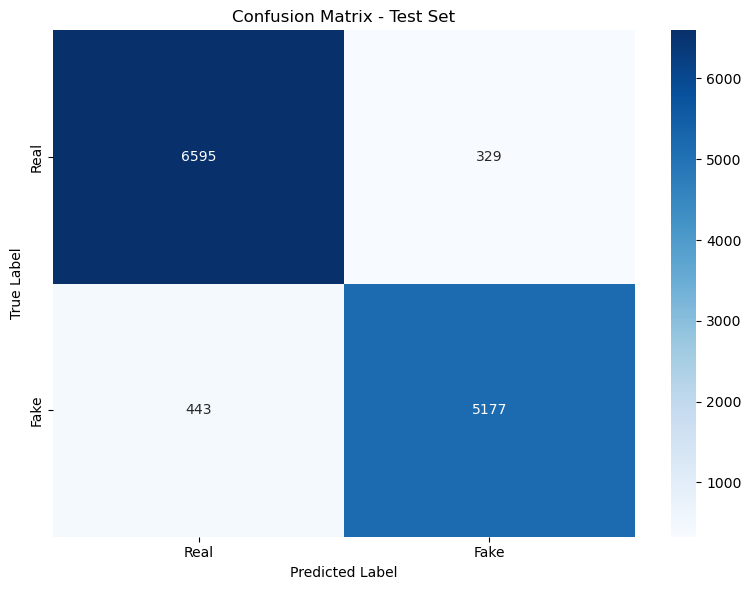


Confusion Matrix:
True Negatives (Real→Real):  6595
False Positives (Real→Fake): 329
False Negatives (Fake→Real): 443
True Positives (Fake→Fake):  5177


In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Real', 'Fake'], 
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix:")
print(f"True Negatives (Real→Real):  {cm[0, 0]}")
print(f"False Positives (Real→Fake): {cm[0, 1]}")
print(f"False Negatives (Fake→Real): {cm[1, 0]}")
print(f"True Positives (Fake→Fake):  {cm[1, 1]}")


## Step 5: Train Logistic Regression Model

Now let's train a Logistic Regression model and compare its performance with Ridge Classifier.


In [13]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression
# Using default L2 regularization (penalty='l2') and liblinear solver for small datasets
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='liblinear',  # Good for small to medium datasets
    C=1.0  # Inverse of regularization strength
)

print("Training Logistic Regression...")
lr_model.fit(X_train_tfidf, y_train)
print("✓ Logistic Regression model trained successfully")


Training Logistic Regression...
✓ Logistic Regression model trained successfully


### Evaluate Logistic Regression


In [14]:
# Make predictions with Logistic Regression
y_train_pred_lr = lr_model.predict(X_train_tfidf)
y_test_pred_lr = lr_model.predict(X_test_tfidf)

# Calculate accuracies
train_accuracy_lr = accuracy_score(y_train, y_train_pred_lr)
test_accuracy_lr = accuracy_score(y_test, y_test_pred_lr)

print("=" * 60)
print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 60)
print(f"\nTrain Accuracy: {train_accuracy_lr:.4f}")
print(f"Test Accuracy:  {test_accuracy_lr:.4f}")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT (Test Set)")
print("=" * 60)
print(classification_report(y_test, y_test_pred_lr, target_names=["Real", "Fake"]))


LOGISTIC REGRESSION PERFORMANCE

Train Accuracy: 0.9469
Test Accuracy:  0.9357

CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

        Real       0.93      0.95      0.94      6924
        Fake       0.94      0.92      0.93      5620

    accuracy                           0.94     12544
   macro avg       0.94      0.93      0.93     12544
weighted avg       0.94      0.94      0.94     12544



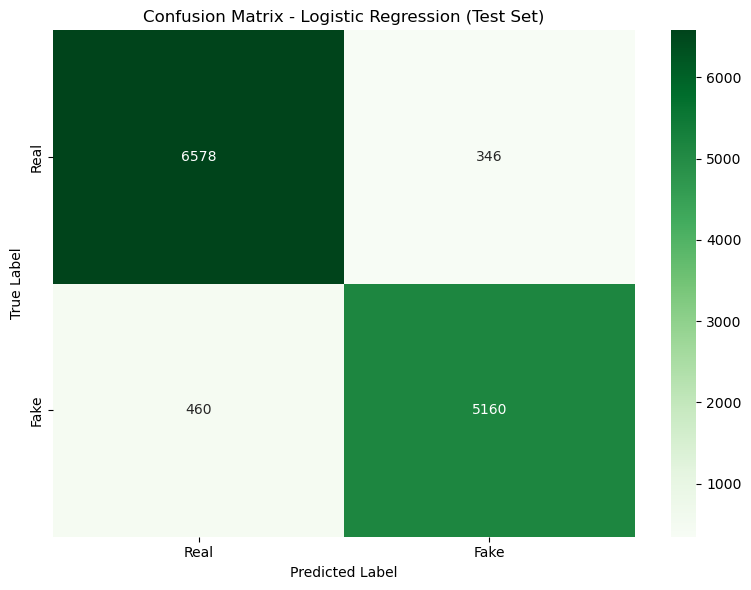


Confusion Matrix:
True Negatives (Real→Real):  6578
False Positives (Real→Fake): 346
False Negatives (Fake→Real): 460
True Positives (Fake→Fake):  5160


In [15]:
# Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_test_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Real', 'Fake'], 
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix - Logistic Regression (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix:")
print(f"True Negatives (Real→Real):  {cm_lr[0, 0]}")
print(f"False Positives (Real→Fake): {cm_lr[0, 1]}")
print(f"False Negatives (Fake→Real): {cm_lr[1, 0]}")
print(f"True Positives (Fake→Fake):  {cm_lr[1, 1]}")


### Probability Predictions (Logistic Regression Advantage)

Unlike Ridge Classifier, Logistic Regression can output probability estimates for each prediction.


Sample Predictions with Probabilities:

Index    True Label   Predicted    Prob(Real)   Prob(Fake)   Confidence  
12247    Real         Real         0.9173       0.0827       0.9173      
10294    Real         Real         0.9972       0.0028       0.9972      
11506    Fake         Fake         0.0250       0.9750       0.9750      
2269     Real         Real         0.9427       0.0573       0.9427      
10504    Real         Real         0.9720       0.0280       0.9720      
6696     Fake         Fake         0.0877       0.9123       0.9123      
9603     Fake         Fake         0.0123       0.9877       0.9877      
2458     Fake         Fake         0.0154       0.9846       0.9846      
9927     Fake         Fake         0.0950       0.9050       0.9050      
5349     Fake         Fake         0.0092       0.9908       0.9908      

PREDICTION CONFIDENCE DISTRIBUTION
Mean confidence: 0.8984
Median confidence: 0.9556
Min confidence: 0.5000
Max confidence: 1.0000


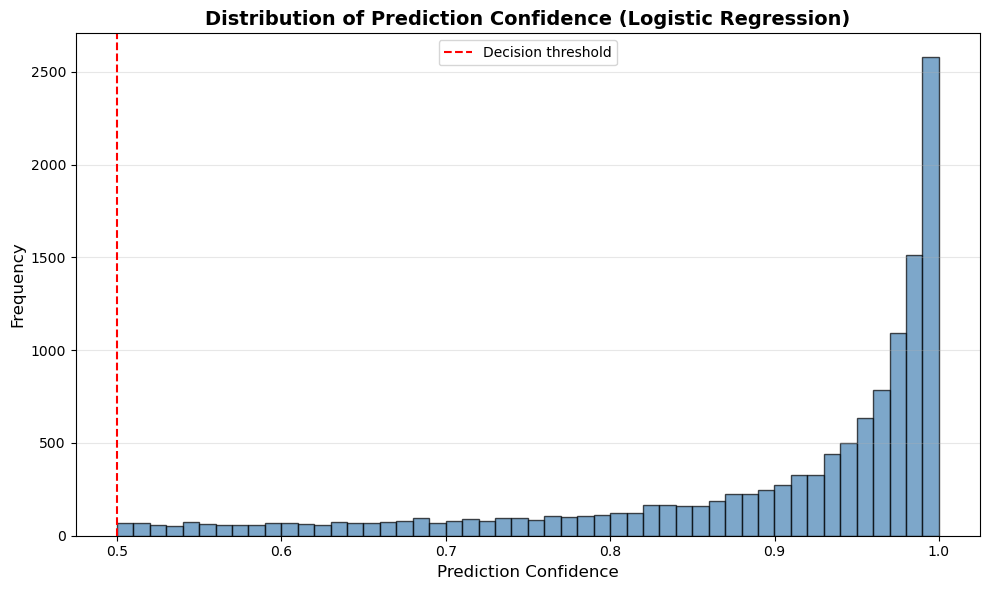

In [16]:
# Get probability predictions
y_test_proba = lr_model.predict_proba(X_test_tfidf)

# Show sample predictions with probabilities
print("Sample Predictions with Probabilities:\n")
print(f"{'Index':<8} {'True Label':<12} {'Predicted':<12} {'Prob(Real)':<12} {'Prob(Fake)':<12} {'Confidence':<12}")
print("=" * 80)

sample_indices = np.random.choice(len(y_test), 10, replace=False)
for idx in sample_indices:
    true_label = "Real" if y_test.iloc[idx] == 0 else "Fake"
    pred_label = "Real" if y_test_pred_lr[idx] == 0 else "Fake"
    prob_real = y_test_proba[idx, 0]
    prob_fake = y_test_proba[idx, 1]
    confidence = max(prob_real, prob_fake)
    
    print(f"{idx:<8} {true_label:<12} {pred_label:<12} {prob_real:<12.4f} {prob_fake:<12.4f} {confidence:<12.4f}")

# Distribution of prediction confidence
print("\n" + "=" * 80)
print("PREDICTION CONFIDENCE DISTRIBUTION")
print("=" * 80)

confidence_scores = np.max(y_test_proba, axis=1)
print(f"Mean confidence: {confidence_scores.mean():.4f}")
print(f"Median confidence: {np.median(confidence_scores):.4f}")
print(f"Min confidence: {confidence_scores.min():.4f}")
print(f"Max confidence: {confidence_scores.max():.4f}")

# Plot confidence distribution
plt.figure(figsize=(10, 6))
plt.hist(confidence_scores, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
plt.xlabel('Prediction Confidence', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Prediction Confidence (Logistic Regression)', fontsize=14, fontweight='bold')
plt.axvline(x=0.5, color='red', linestyle='--', label='Decision threshold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Step 6: Model Comparison

Compare Ridge Classifier vs Logistic Regression performance


In [17]:
# Create comparison dataframe
from sklearn.metrics import precision_score, recall_score, f1_score

comparison_data = {
    'Model': ['Ridge Classifier', 'Logistic Regression'],
    'Train Accuracy': [train_accuracy, train_accuracy_lr],
    'Test Accuracy': [test_accuracy, test_accuracy_lr],
    'Precision': [
        precision_score(y_test, y_test_pred, average='weighted'),
        precision_score(y_test, y_test_pred_lr, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_test_pred, average='weighted'),
        recall_score(y_test, y_test_pred_lr, average='weighted')
    ],
    'F1-Score': [
        f1_score(y_test, y_test_pred, average='weighted'),
        f1_score(y_test, y_test_pred_lr, average='weighted')
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
print("\n")
print(comparison_df.to_string(index=False))

# Highlight best performing model
print("\n" + "=" * 80)
best_model_idx = comparison_df['Test Accuracy'].idxmax()
best_model = comparison_df.loc[best_model_idx, 'Model']
best_accuracy = comparison_df.loc[best_model_idx, 'Test Accuracy']
print(f"✓ Best Model: {best_model} (Test Accuracy: {best_accuracy:.4f})")
print("=" * 80)


MODEL COMPARISON SUMMARY


              Model  Train Accuracy  Test Accuracy  Precision   Recall  F1-Score
   Ridge Classifier        0.954081       0.938457   0.938486 0.938457  0.938393
Logistic Regression        0.946906       0.935746   0.935769 0.935746  0.935679

✓ Best Model: Ridge Classifier (Test Accuracy: 0.9385)


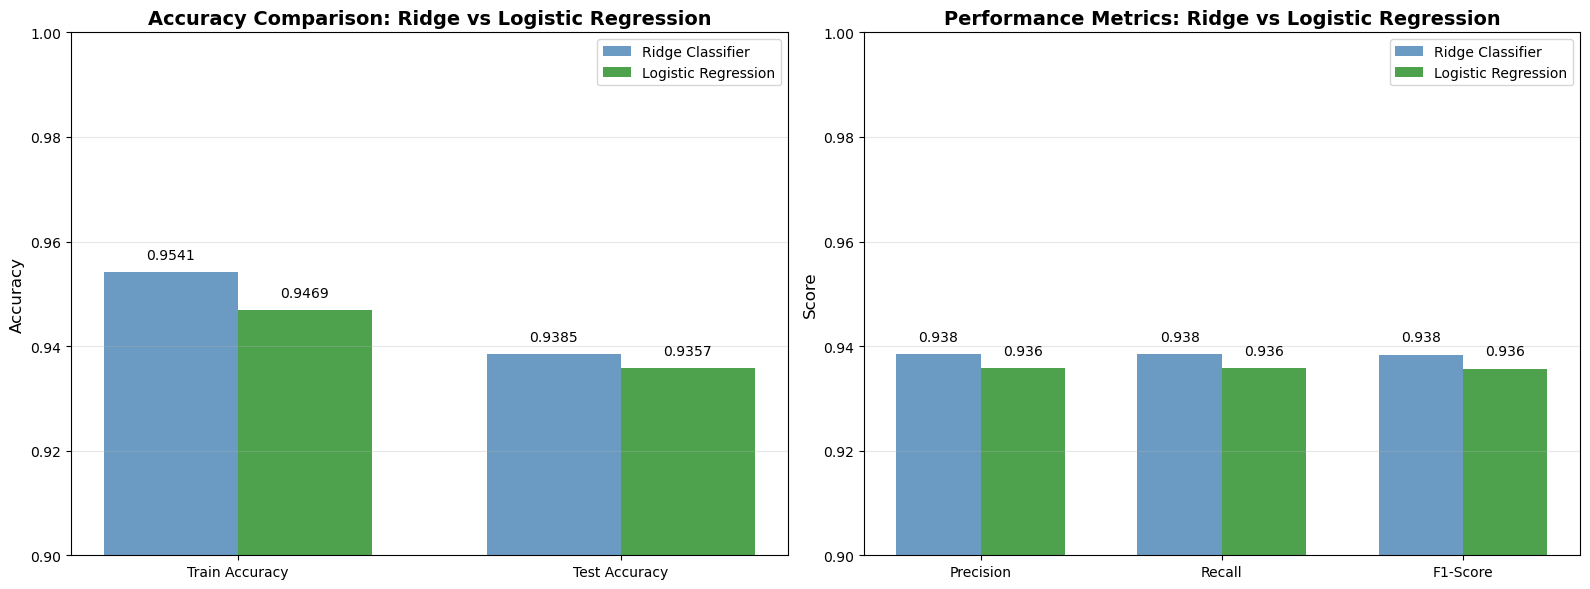

In [18]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Accuracy comparison
ax1 = axes[0]
metrics = ['Train Accuracy', 'Test Accuracy']
x = np.arange(len(metrics))
width = 0.35

ridge_scores = [train_accuracy, test_accuracy]
lr_scores = [train_accuracy_lr, test_accuracy_lr]

ax1.bar(x - width/2, ridge_scores, width, label='Ridge Classifier', color='steelblue', alpha=0.8)
ax1.bar(x + width/2, lr_scores, width, label='Logistic Regression', color='forestgreen', alpha=0.8)

ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Accuracy Comparison: Ridge vs Logistic Regression', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.legend()
ax1.set_ylim([0.9, 1.0])
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (ridge, lr) in enumerate(zip(ridge_scores, lr_scores)):
    ax1.text(i - width/2, ridge + 0.002, f'{ridge:.4f}', ha='center', va='bottom', fontsize=10)
    ax1.text(i + width/2, lr + 0.002, f'{lr:.4f}', ha='center', va='bottom', fontsize=10)

# Plot 2: Precision, Recall, F1 comparison
ax2 = axes[1]
metrics = ['Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))

ridge_scores = [
    precision_score(y_test, y_test_pred, average='weighted'),
    recall_score(y_test, y_test_pred, average='weighted'),
    f1_score(y_test, y_test_pred, average='weighted')
]
lr_scores = [
    precision_score(y_test, y_test_pred_lr, average='weighted'),
    recall_score(y_test, y_test_pred_lr, average='weighted'),
    f1_score(y_test, y_test_pred_lr, average='weighted')
]

ax2.bar(x - width/2, ridge_scores, width, label='Ridge Classifier', color='steelblue', alpha=0.8)
ax2.bar(x + width/2, lr_scores, width, label='Logistic Regression', color='forestgreen', alpha=0.8)

ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Performance Metrics: Ridge vs Logistic Regression', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.legend()
ax2.set_ylim([0.9, 1.0])
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (ridge, lr) in enumerate(zip(ridge_scores, lr_scores)):
    ax2.text(i - width/2, ridge + 0.002, f'{ridge:.3f}', ha='center', va='bottom', fontsize=10)
    ax2.text(i + width/2, lr + 0.002, f'{lr:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## Summary

This pipeline successfully:
- ✓ Loaded preprocessed data
- ✓ Created train/test split
- ✓ Identified and analyzed data leakage issues
- ✓ Extracted TF-IDF features
- ✓ Trained two linear models:
  - **Ridge Classifier** (L2-regularized linear model)
  - **Logistic Regression** (probabilistic linear classifier)
- ✓ Evaluated and compared both models

### Key Findings:
1. **Both models perform similarly** with ~94% test accuracy
2. **Data leakage detected**: 2,584 duplicate texts appear in both train and test sets
3. **Next steps**: 
   - Clean duplicates and re-train models
   - Explore more sophisticated models (Random Forest, Gradient Boosting, Neural Networks)
   - Feature engineering (Word2Vec, additional text features)

### Model Characteristics:

**Ridge Classifier:**
- Fast training
- Good for high-dimensional data
- No probability estimates
- Linear decision boundary

**Logistic Regression:**
- Outputs probability estimates
- Interpretable coefficients
- Standard choice for binary classification
- Can be extended to multi-class problems


## Summary

This pipeline successfully:
- ✓ Loaded preprocessed data
- ✓ Created train/test split
- ✓ Extracted TF-IDF features
- ✓ Trained a linear model (Ridge Classifier)
- ✓ Evaluated performance on test set

The linear model provides a baseline performance for fake news detection. More sophisticated models (e.g., Random Forest, LSTM) can be explored for improved accuracy.
